# Matching and comparison of the database with external sources

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import ast
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter
import matplotlib.pyplot as plt

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS

path_save_fig = DATA_FIGURE / "validation_external_sources"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# 200 reports 
# res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
# res_name_llm = "filtered_post_processed_geocoded_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225"
# res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_v120226_geo"
cols = [
    "appealCode", 
    "reportDate",
    "impactSubtype", 
    "impactValue", 
    "impactValueMin", 
    "impactValueMax", 
    "impactValuePrecision", 
    "impactUnit",
    "valueAnnotation", 
    "location", 
    "locationAnnotation", 
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards", 
    'startYear', 
    'startMonth', 
    'startDay', 
    'endYear', 
    'endMonth', 
    'endDay'
]
# df_llm_all_geo = pd.read_parquet(DATA_OUT_PROC/(res_name_llm+'.parquet'), columns=cols)
df_llm_all = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.csv'), encoding='utf-8')
# df_llm_all = format_output(df_llm_all, list_cols=LIST_COLS+["country_robust_iso3"])
# df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'_geo_v191225.gpkg'))

# col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
# df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

# col_to_list = ["location", "locationPolygon", "iso3_code", "hazards"]
# df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))

In [5]:
col_to_list = ["location", "hazards", "country_robust_iso3"]
df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

In [146]:
df_llm_all_geo_grp = clean_group(df_llm_all, ADM_min=0)

In [147]:
# Import data from other sources
df_ifrc_go = open_clean_ifrc_go()
df_ifrc_monty = open_clean_ifrc_monty(df_ifrc_go)
df_em_dat = open_emdat()

df_external_source = {}
df_external_source["ifrc_go"] = df_ifrc_go
df_external_source["ifrc_monty"] = df_ifrc_monty
df_external_source["emdat"] = df_em_dat

In [148]:
print("Number of unique appealCode from the IFRCGO API : ", df_external_source["ifrc_go"]["appealCode"].nunique())
print("Number of unique common appealCode with the LLM-extracted reports : ", df_llm_all_geo_grp.loc[df_llm_all_geo_grp["appealCode"].isin(df_external_source["ifrc_go"]["appealCode"].unique())]["appealCode"].nunique())

Number of unique appealCode from the IFRCGO API :  2728
Number of unique common appealCode with the LLM-extracted reports :  614


In [149]:
df_llm_all_geo_grp_linked = {}

# MATCHING WITH IFRC MONTY 
df_ifrc_monty_subset = df_ifrc_monty[["appealCode", "impact_type", "impact_value", "impact_category"]]
df_llm_all_geo_grp_linked["ifrc_monty"] = df_llm_all_geo_grp.merge(df_ifrc_monty_subset, left_on=["appealCode", "impactSubtype"], right_on=["appealCode", "impact_type"])

# MATCHING WITH IFRC GO
df_llm_all_geo_grp_linked["ifrc_go"] = df_llm_all_geo_grp.merge(df_ifrc_go, on=["appealCode"])

# MATCHING WITH EMDAT
months = 3
date_diff_th = datetime.timedelta(days=months*30)
df_llm_all_geo_linked, df_llm_em_dat = matching_emdat(df_llm_all_geo_grp, df_em_dat, date_diff_th, "date_diff_start", country_field='country_robust_iso3')
df_llm_all_geo_grp_linked["emdat"] = df_llm_all_geo_linked

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\external_comparaison.py:398: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [150]:
print("Number of unique appealCode from the IFRCGO API : ", df_external_source["emdat"]["DisNo."].nunique())

Number of unique appealCode from the IFRCGO API :  14935


# Global plots

Need to plot informations about the raw dataset, such as : 
- Map with the number of event per country --> Need to filter over the same period 
- Total number of affected people (per year per country ?)
- % of reports for which we have information about each Impact Category (before matching with the ones extracted with LLM)

### Plot of % of reports with impact information 

In [151]:
df_external_source["ifrc_go"]["disaster_start_date"] = pd.to_datetime(df_external_source["ifrc_go"]["disaster_start_date"],
    errors='coerce')

In [152]:
nb_report_with_impact = {}
perc_report_with_impact = {}

In [153]:
external_source = "ifrc_go"

nb_report_with_impact[external_source] = []
perc_report_with_impact[external_source] = []

df_impact_ext = df_external_source[external_source]

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_go']
    if col is None :
        nb_report_with_impact[external_source].append(0)
        perc_report_with_impact[external_source].append(0)
        continue
    n = len(df_impact_ext.dropna(subset=impactSubtype))
    nb_report_with_impact[external_source].append(n)
    perc_report_with_impact[external_source].append(100*n/len(df_impact_ext))


In [154]:
external_source = "emdat"

nb_report_with_impact[external_source] = []
perc_report_with_impact[external_source] = []

df_impact_ext = df_external_source[external_source]

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['emdat']
    if col is None :
        nb_report_with_impact[external_source].append(0)
        perc_report_with_impact[external_source].append(0)
        continue
    n = len(df_impact_ext.dropna(subset=col))
    nb_report_with_impact[external_source].append(n)
    perc_report_with_impact[external_source].append(100*n/len(df_impact_ext))


In [155]:
nb_report_with_impact_llm = []
perc_report_with_impact_llm = []

for impactSubtype in mapping_impact_type.keys() : 
    df_impact_ext = df_llm_all_geo_grp.loc[df_llm_all_geo_grp["impactSubtype"]==impactSubtype]
    n = df_impact_ext.dropna(subset="impactValue_final")["appealCode"].nunique()
    nb_report_with_impact_llm.append(n)
    perc_report_with_impact_llm.append(100*n/df_llm_all_geo_grp["appealCode"].nunique())


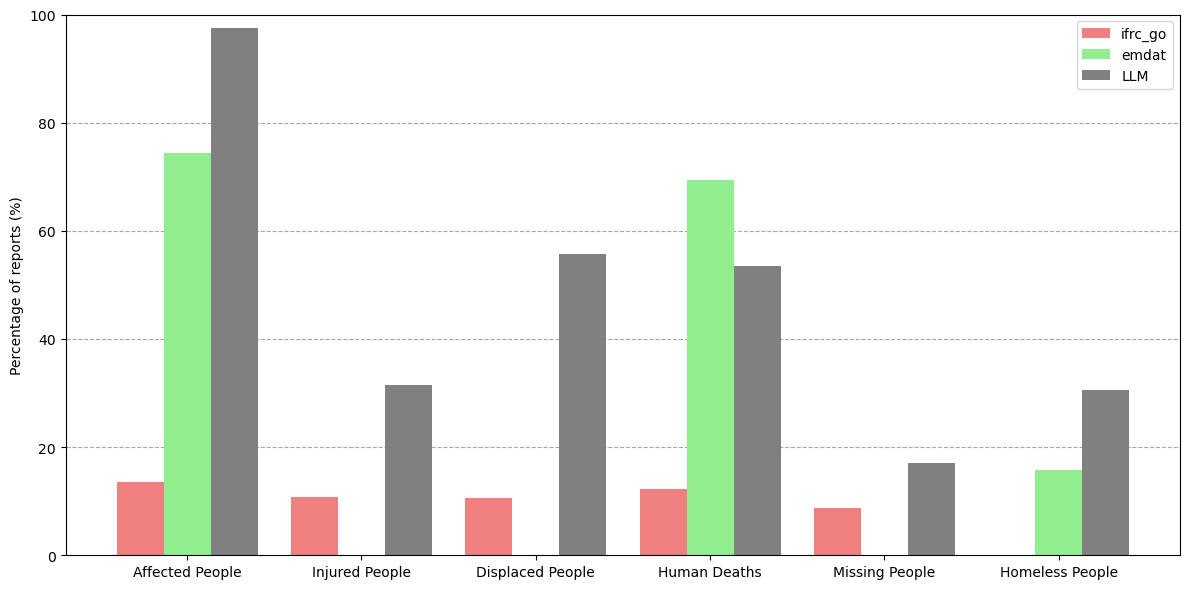

In [156]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.27  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors = {}
colors["ifrc_monty"] = ["skyblue", "dodgerblue"]      # all / perfect match
colors["emdat"] = ["lightgreen", "green"]       # all / perfect match
colors["ifrc_go"] = ["lightcoral", "brown"]

for i, external_source in enumerate(perc_report_with_impact.keys()) : 
    # IFRC bars
    ax.bar(x + (i-1)*width, perc_report_with_impact[external_source], width, label=external_source, color=colors[external_source][0])

ax.bar(x + width, perc_report_with_impact_llm, width, label="LLM", color="grey")
# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys())
# ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel(r"Percentage of reports (%)")
# ax.set_title(r"Percentage of events with impact value")
ax.legend()

for y in [20, 40, 60, 80]:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

ax.set_ylim(0, 100)

plt.tight_layout()
# fig.savefig(path_save_fig / f"percentage_events_quanti_impact.png", 
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"percentage_events_quanti_impact.svg", 
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"percentage_events_quanti_impact.pdf", 
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

## Bar Plot after event matching

In [157]:
nb_matched = {}
nb_exact_match = {}
nb_no_match = {}
nb_no_external_impact = {}
df_matched_with_impact = {}

tolerance = 0.10

In [ ]:
# Number mapped and nb with exact matching 
external_source = "ifrc_monty"
nb_matched[external_source] = []
nb_exact_match[external_source] = []
df_matched_with_impact[external_source] = pd.DataFrame()

# Compute differences
df_llm_all_geo_grp_linked[external_source]["abs_diff"] = abs(
    df_llm_all_geo_grp_linked[external_source]["impact_value"]
    - df_llm_all_geo_grp_linked[external_source]["impactValue_final"]
)

# Compute relative difference (avoid division by zero)
df_llm_all_geo_grp_linked[external_source]["rel_diff"] = (
    df_llm_all_geo_grp_linked[external_source]["abs_diff"]
    / df_llm_all_geo_grp_linked[external_source]["impactValue_final"].replace(0, np.nan)
)

# Mark rows as "match" if within tolerance
df_llm_all_geo_grp_linked[external_source]["match"] = df_llm_all_geo_grp_linked[external_source]["rel_diff"] <= tolerance

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_monty']
    if col is None :
        nb_matched[external_source].append(0)
        nb_exact_match[external_source].append(0)
        continue

    df_matched = df_llm_all_geo_grp_linked[external_source].loc[
        df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype
    ]

    df_matched_with_impact[external_source] = pd.concat(
        [df_matched_with_impact[external_source], df_matched],
        axis=0,
        ignore_index=True,
    )

    nb_matched[external_source].append(df_matched["appealCode"].nunique())
    nb_exact_match[external_source].append(df_matched.loc[df_matched["match"]]["appealCode"].nunique())

In [172]:
# Number mapped and nb with exact matching 
external_source = "ifrc_go"
nb_matched[external_source] = []
nb_exact_match[external_source] = []
nb_no_external_impact[external_source] = []
df_matched_with_impact[external_source] = pd.DataFrame()

for impactSubtype in mapping_impact_type.keys() : 
    col = mapping_impact_type[impactSubtype]['ifrc_go']
    if col is None :
        nb_matched[external_source].append(0)
        nb_exact_match[external_source].append(0)
        nb_no_external_impact[external_source].append(0)
        continue

    df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]
    n_before = len(df_matched)
    df_matched = df_matched.dropna(subset=[impactSubtype])
    n_after = len(df_matched)

    # Compute differences safely
    df_matched["abs_diff"] = abs(df_matched["impactValue_final"] - df_matched[impactSubtype])

    denom = (abs(df_matched["impactValue_final"]) + abs(df_matched[impactSubtype])) / 2
    denom = denom.replace(0, np.nan)
    # Signed relative difference (keeps over/under-estimation direction)
    # df_matched["rel_diff"] = (df_matched["impactValue_final"] - df_matched[impactSubtype]) / denom
    df_matched["rel_diff"] = (df_matched[impactSubtype] - df_matched["impactValue_final"]) / df_matched["impactValue_final"].replace(0, np.nan)
    df_matched["abs_rel_diff"] = df_matched["rel_diff"].abs()

    # Match if absolute relative difference <= tolerance
    df_matched["match"] = df_matched["abs_rel_diff"] <= tolerance
    df_matched_with_impact[external_source] = pd.concat(
        [df_matched_with_impact[external_source], df_matched],
        axis=0,
        ignore_index=True,
    )
    
    nb_no_external_impact[external_source].append(n_before-n_after)
    nb_matched[external_source].append(df_matched["appealCode"].nunique())
    nb_exact_match[external_source].append(df_matched.loc[df_matched["match"]]["appealCode"].nunique())

In [173]:
# Number mapped and nb with exact matching 
external_source = "emdat"
nb_matched[external_source] = []
nb_exact_match[external_source] = []
nb_no_external_impact[external_source] = []
df_matched_with_impact[external_source] = pd.DataFrame()

for impactSubtype in mapping_impact_type.keys() : 
    emdat_col = mapping_impact_type[impactSubtype][external_source]
    if emdat_col is None :
        nb_matched[external_source].append(0)
        nb_exact_match[external_source].append(0)
        nb_no_external_impact[external_source].append(0)
        continue

    df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]
    n_before = len(df_matched)
    # print(n_before, df_matched["appealCode"].nunique())
    df_matched = df_matched.dropna(subset=[mapping_impact_type[impactSubtype][external_source]])
    n_after = len(df_matched)
    # print(emdat_col, n_before, n_after, df_matched["appealCode"].nunique())

    # Compute differences safely
    df_matched["abs_diff"] = abs(df_matched["impactValue_final"] - df_matched[mapping_impact_type[impactSubtype][external_source]])

    denom = (
        abs(df_matched["impactValue_final"])
        + abs(df_matched[mapping_impact_type[impactSubtype][external_source]])
    ) / 2
    denom = denom.replace(0, np.nan)
    # Signed relative difference (keeps over/under-estimation direction)
    df_matched["rel_diff"] = (df_matched[mapping_impact_type[impactSubtype][external_source]] - df_matched["impactValue_final"]) / df_matched["impactValue_final"].replace(0, np.nan)
    df_matched["abs_rel_diff"] = df_matched["rel_diff"].abs()

    # Match if absolute relative difference <= tolerance
    df_matched["match"] = df_matched["abs_rel_diff"] <= tolerance
    df_matched_with_impact[external_source] = pd.concat(
        [df_matched_with_impact[external_source], df_matched],
        axis=0,
        ignore_index=True,
    )

    nb_no_external_impact[external_source].append(n_before-n_after)
    nb_matched[external_source].append(df_matched["appealCode"].nunique())
    nb_exact_match[external_source].append(df_matched.loc[df_matched["match"]]["appealCode"].nunique())

In [176]:
df_matched_with_impact["ifrc_go"].rel_diff.describe()

count      853.000000
mean       103.041664
std       2583.598673
min         -1.000000
25%         -0.818182
50%         -0.245283
75%          0.000000
max      75265.462440
Name: rel_diff, dtype: float64

In [161]:
nb_extracted = []
for impactSubtype in mapping_impact_type.keys() : 
    nb_extracted.append(df_llm_all_geo_grp.loc[df_llm_all_geo_grp["impactSubtype"]==impactSubtype].dropna(subset=["impactValue_final"])["appealCode"].nunique())

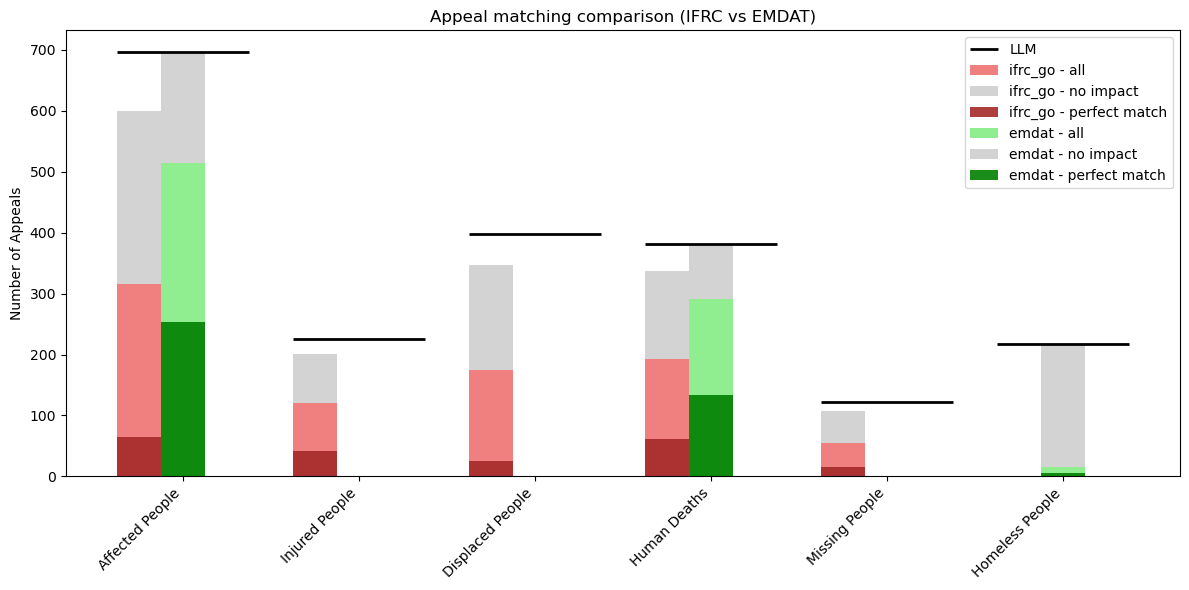

In [162]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors
colors = {
    "ifrc_monty": ["skyblue", "dodgerblue"],
    "emdat": ["lightgreen", "green"],
    "ifrc_go": ["lightcoral", "brown"],
}

for i, external_source in enumerate(["ifrc_go", "emdat"]):
    # Base bars ("all")
    bars_all = ax.bar(
        x + (i-1)*width,
        nb_matched[external_source],
        width,
        label=external_source + " - all",
        color=colors[external_source][0],
    )

    # Add stacked bar ("no external impact") on top of "all"
    ax.bar(
        x + (i-1)*width,
        nb_no_external_impact[external_source],
        width,
        bottom=nb_matched[external_source],
        label=external_source + " - no impact",
        color="lightgray",
        # edgecolor="gray",
    )

    # "Perfect match" bars
    ax.bar(
        x + (i-1)*width,
        nb_exact_match[external_source],
        width,
        label=external_source + " - perfect match",
        color=colors[external_source][1],
        alpha=0.9,
    )

# Target lines
total_bar_width = 3*width
for xi, y in zip(x, nb_extracted):
    ax.hlines(
        y=y,
        xmin=xi - total_bar_width/2,
        xmax=xi + total_bar_width/2,
        colors='black',
        linewidth=2,
        label="LLM" if xi == 0 else ""
    )

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of Appeals")
ax.set_title("Appeal matching comparison (IFRC vs EMDAT)")
ax.legend()
plt.tight_layout()
plt.show()

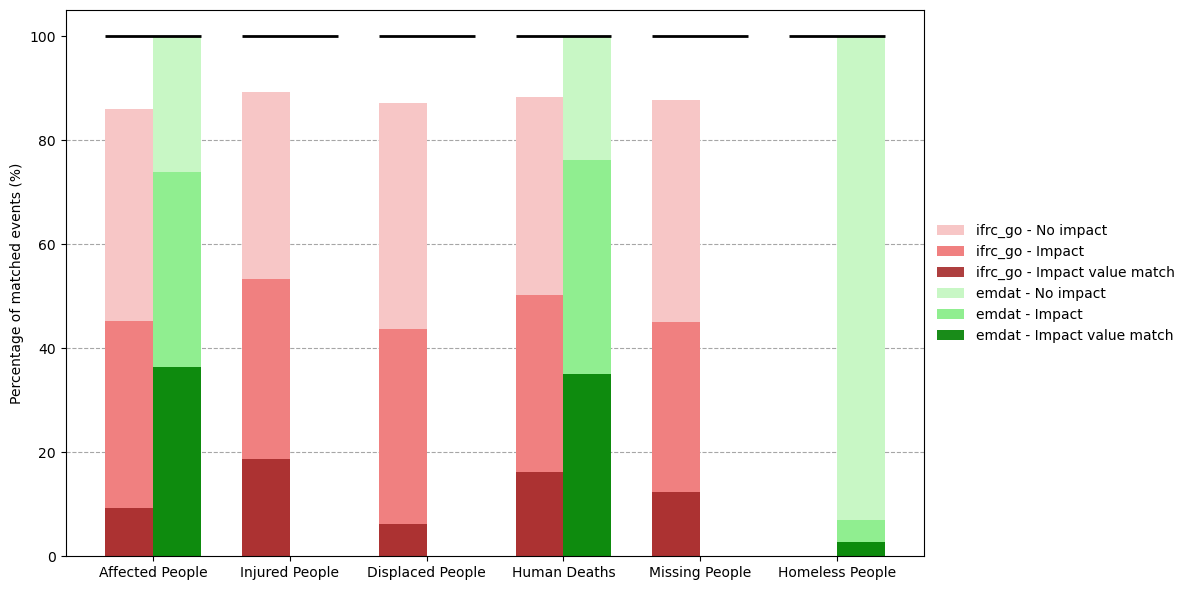

In [163]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # wider bar width

fig, ax = plt.subplots(figsize=(12, 6))

# Define colors
colors = {
    "emdat": {
        "all": "lightgreen",
        "no_impact": "#c8f7c5",  # very light green
        "exact": "green",
    },
    "ifrc_go": {
        "all": "lightcoral",
        "no_impact": "#f7c6c6",  # very light red
        "exact": "brown",
    },
}

# Convert counts to percentages of nb_extracted
nb_matched_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_matched.items()}
nb_no_external_impact_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_no_external_impact.items()}
nb_exact_match_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_exact_match.items()}

for i, external_source in enumerate(["ifrc_go", "emdat"]):
    offset = (i - 0.5) * width  # positions for side-by-side bars

    # Combine total (all + no external impact + exact match) as one stacked bar
    ax.bar(
        x + offset,
        nb_no_external_impact_pct[external_source],
        width,
        bottom=nb_matched_pct[external_source],
        label=external_source + " - No impact",
        color=colors[external_source]["no_impact"],
    )
    
    ax.bar(
        x + offset,
        nb_matched_pct[external_source],
        width,
        label=external_source + " - Impact",
        color=colors[external_source]["all"],
    )

    ax.bar(
        x + offset,
        nb_exact_match_pct[external_source],
        width,
        label=external_source + " - Impact value match",
        color=colors[external_source]["exact"],
        alpha=0.9,
    )

# Reference line at 100%
for xi in x:
    ax.hlines(
        y=100,
        xmin=xi - width,
        xmax=xi + width,
        colors='black',
        linewidth=2
    )

# Add dashed horizontal gridlines at 20, 40, 60, 80%
for y in [20, 40, 60, 80]:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# Labels and formatting
ax.set_xticks(x)
# ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_xticklabels(mapping_impact_type.keys())
ax.set_ylabel("Percentage of matched events (%)")
ax.set_ylim(0, 105)
# ax.set_title("Appeal matching comparison (IFRC vs EMDAT) — % of extracted appeals")
ax.legend()

# Move the legend box outside 
ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False
)
plt.tight_layout()

#Save fig 
# fig.savefig(path_save_fig / f"matched_events_ext_quanti_impact.png", 
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"matched_events_ext_quanti_impact.svg", 
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"matched_events_ext_quanti_impact.pdf", 
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()

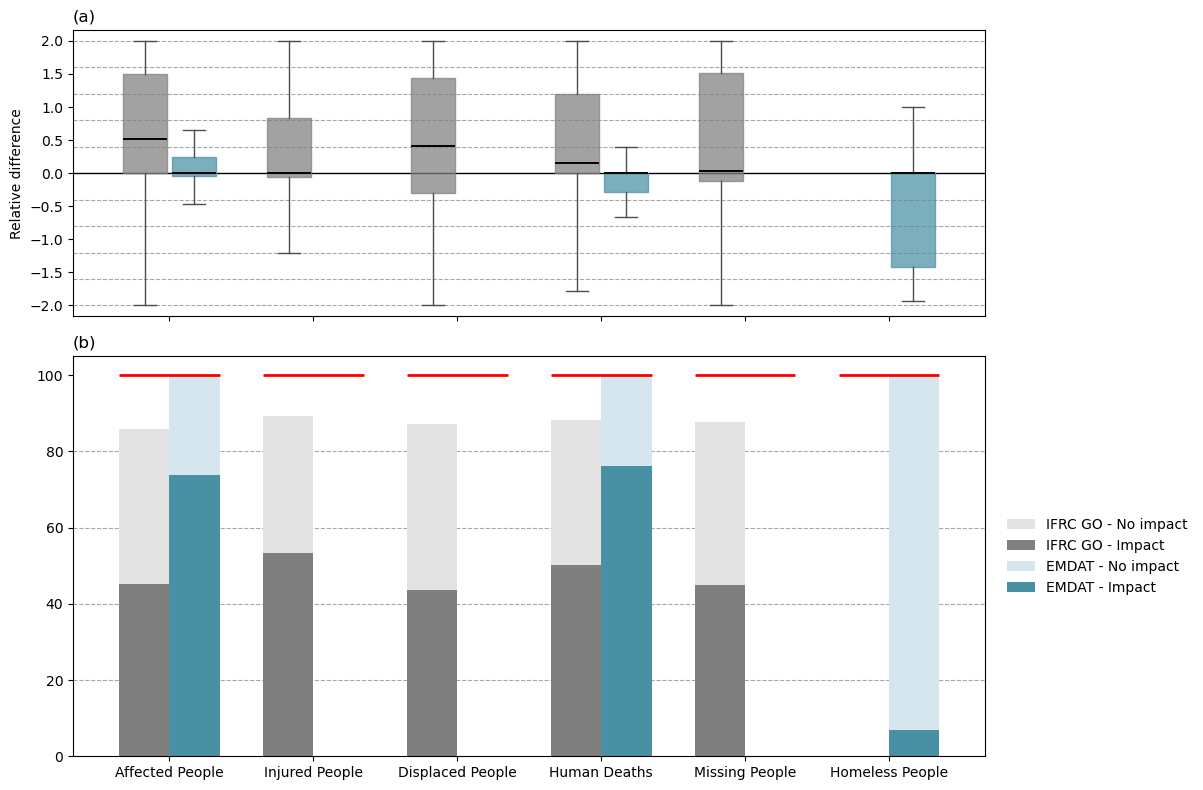

In [164]:
impact_categories = list(mapping_impact_type.keys())
x = np.arange(len(impact_categories))

# Shared colors
color_ifrc = "#7f7f7f"   # medium grey
color_emdat = "#4a90a4"  # muted blue-grey

fig, (ax_err, ax_bar) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    gridspec_kw={"height_ratios": [1, 1.4]},
    sharex=True,
    constrained_layout=False,
 )

# =====================
# 1) Error plot (rel_diff)
# =====================
width_box = 0.34
box_data = []
box_positions = []
box_colors = []

for i, impactSubtype in enumerate(impact_categories):
    vals_ifrc = (
        df_matched_with_impact.get("ifrc_go", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "rel_diff"]
        .dropna()
        .values
    )
    vals_emdat = (
        df_matched_with_impact.get("emdat", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "rel_diff"]
        .dropna()
        .values
    )

    if len(vals_ifrc) > 0:
        box_data.append(vals_ifrc)
        box_positions.append(i - width_box / 2)
        box_colors.append(color_ifrc)

    if len(vals_emdat) > 0:
        box_data.append(vals_emdat)
        box_positions.append(i + width_box / 2)
        box_colors.append(color_emdat)

if box_data:
    bp = ax_err.boxplot(
        box_data,
        positions=box_positions,
        widths=width_box * 0.9,
        patch_artist=True,
        showfliers=False,
    )

    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.72)
        patch.set_edgecolor(c)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.4)

    for whisker in bp["whiskers"]:
        whisker.set_color("#4d4d4d")

    for cap in bp["caps"]:
        cap.set_color("#4d4d4d")

    max_abs = np.nanmax(np.abs(np.concatenate([arr for arr in box_data if len(arr) > 0])))
    if not np.isfinite(max_abs) or max_abs <= 0:
        max_abs = 1
else:
    max_abs = 1

ylim = max_abs * 1.08
ax_err.set_ylim(-ylim, ylim)

# Dashed gridlines for both positive and negative values
grid_levels = np.linspace(0, max_abs, 6)[1:]
for y in grid_levels:
    ax_err.axhline(y=y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
    ax_err.axhline(y=-y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
ax_err.axhline(y=0, color="black", linewidth=1, zorder=1)

ax_err.set_ylabel("Relative difference")
ax_err.set_title("(a)", loc="left")

# err_legend_handles = [
#     plt.Line2D([0], [0], color=color_ifrc, lw=10, alpha=0.72, label="IFRC GO"),
#     plt.Line2D([0], [0], color=color_emdat, lw=10, alpha=0.72, label="EMDAT"),
# ]
# ax_err.legend(handles=err_legend_handles, loc="upper right", frameon=False)

# =====================
# 2) matched_events_ext_quanti_impact plot
# =====================
width = 0.35

colors = {
    "emdat": {
        "all": "#4a90a4",        # light desaturated blue
        "no_impact": "#d6e6ef",  # very light blue
        # "all": "#b8d4e3",        # light desaturated blue
        # "no_impact": "#d6e6ef",  # very light blue
        # "exact": "#4a90a4",      # muted blue-grey
    },
    "ifrc_go": {
        "all": "#7f7f7f",        # light grey
        "no_impact": "#e3e3e3",  # very light grey
        # "all": "#c8c8c8",        # light grey
        # "no_impact": "#e3e3e3",  # very light grey
        # "exact": "#7f7f7f",      # medium grey
    },
}

# Convert counts to percentages of nb_extracted
nb_matched_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_matched.items()}
nb_no_external_impact_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_no_external_impact.items()}
# nb_exact_match_pct = {k: (np.array(v) / np.array(nb_extracted)) * 100 for k, v in nb_exact_match.items()}

for i, external_source in enumerate(["ifrc_go", "emdat"]):
    offset = (i - 0.5) * width
    source_label = external_source.replace("_", " ").upper()

    # No external impact (top segment)
    ax_bar.bar(
        x + offset,
        nb_no_external_impact_pct[external_source],
        width,
        bottom=nb_matched_pct[external_source],
        label=source_label + " - No impact",
        color=colors[external_source]["no_impact"],
    )

    # Matched (middle segment)
    ax_bar.bar(
        x + offset,
        nb_matched_pct[external_source],
        width,
        label=source_label + " - Impact",
        color=colors[external_source]["all"],
    )

    # # Exact match (overlay)
    # ax_bar.bar(
    #     x + offset,
    #     nb_exact_match_pct[external_source],
    #     width,
    #     label=source_label + " - Impact value match",
    #     color=colors[external_source]["exact"],
    #     alpha=0.9,
    # )

# Reference 100% line
for xi in x:
    ax_bar.hlines(y=100, xmin=xi - width, xmax=xi + width, colors='red', linewidth=2)

# Horizontal dashed lines
for y in [20, 40, 60, 80]:
    ax_bar.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# # Quantitative markers
# marker_color_ifrc = "dimgray"
# marker_color_emdat = "#4a90a4"
# marker_color_llm = "red"

# pos_ifrc_go = x - width/2
# pos_emdat = x + width/2
# pos_llm = x

# ax_bar.scatter(
#     pos_ifrc_go,
#     perc_report_with_impact["ifrc_go"],
#     marker='s',
#     s=90,
#     color=marker_color_ifrc,
#     label="IFRC GO (quantitative)",
#     zorder=12
# )

# ax_bar.scatter(
#     pos_emdat,
#     perc_report_with_impact["emdat"],
#     marker='s',
#     s=90,
#     color=marker_color_emdat,
#     label="EMDAT (quantitative)",
#     zorder=12
# )

# ax_bar.scatter(
#     pos_llm,
#     perc_report_with_impact_llm,
#     marker='s',
#     s=90,
#     color=marker_color_llm,
#     label="LLM (quantitative)",
#     zorder=12
# )

# ax2.set_ylim(0, 100)

# Formatting
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(impact_categories)
ax_bar.set_ylabel("")
ax_bar.set_ylim(0, 105)
ax_bar.set_title("(b)", loc="left")

# Combined legend for bottom panel
handles1, labels1 = ax_bar.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()
ax_bar.legend(
    handles1,
    labels1,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
 )

plt.tight_layout()

# Save combined figure if needed
# fig.savefig(path_save_fig / "matched_events_ext_quanti_impact_with_error.png",
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "matched_events_ext_quanti_impact_with_error.svg",
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "matched_events_ext_quanti_impact_with_error.pdf",
#             format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()

## Error plot

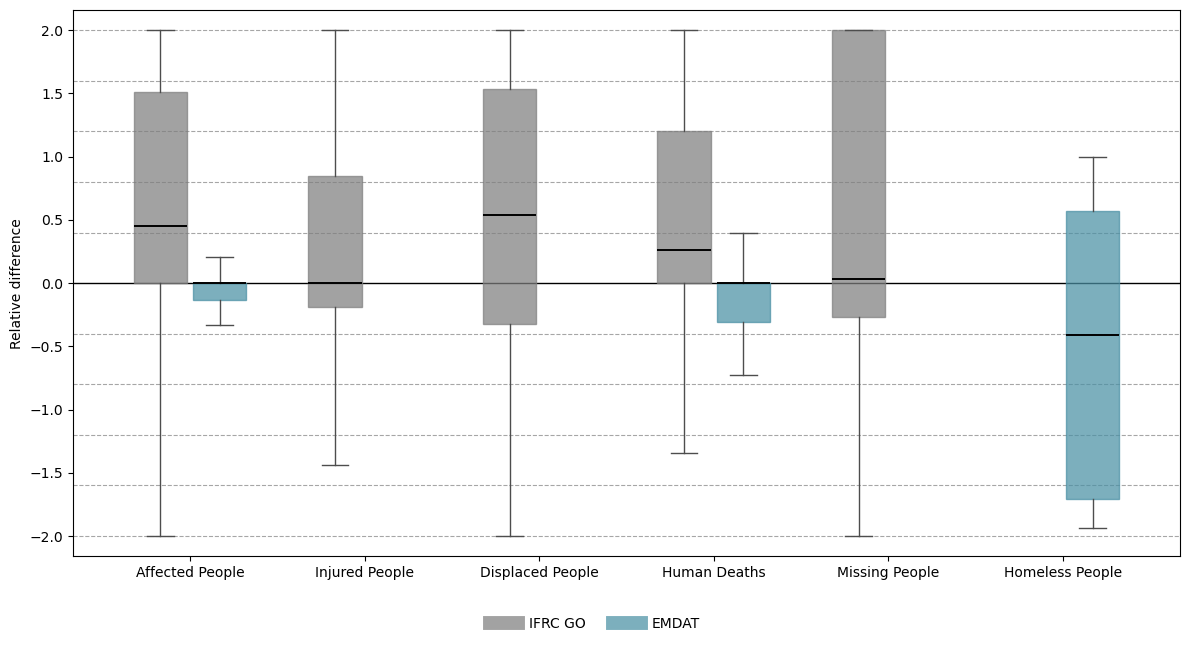

In [46]:
# Relative difference boxplot by impact category (style aligned with the stacked chart)
impact_categories = list(mapping_impact_type.keys())
x = np.arange(len(impact_categories))
width = 0.34

# Colors aligned with your previous figure
color_ifrc = "#7f7f7f"   # medium grey
color_emdat = "#4a90a4"  # muted blue-grey

fig, ax = plt.subplots(figsize=(12, 6))

# Build grouped boxplot data
box_data = []
box_positions = []
box_colors = []

for i, impactSubtype in enumerate(impact_categories):
    vals_ifrc = (
        df_matched_with_impact.get("ifrc_go", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "rel_diff"]
        .dropna()
        .values
    )
    vals_emdat = (
        df_matched_with_impact.get("emdat", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "rel_diff"]
        .dropna()
        .values
    )

    if len(vals_ifrc) > 0:
        box_data.append(vals_ifrc)
        box_positions.append(i - width / 2)
        box_colors.append(color_ifrc)

    if len(vals_emdat) > 0:
        box_data.append(vals_emdat)
        box_positions.append(i + width / 2)
        box_colors.append(color_emdat)

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=width * 0.9,
    patch_artist=True,
    showfliers=False,
)
# bp = ax.violinplot(
#     box_data,
#     positions=box_positions,
#     widths=width * 0.9,
#     # patch_artist=True,
#     # showfliers=False,
# )

for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.72)
    patch.set_edgecolor(c)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.4)

for whisker in bp["whiskers"]:
    whisker.set_color("#4d4d4d")

for cap in bp["caps"]:
    cap.set_color("#4d4d4d")

# Dynamic symmetric y-limits based on rel_diff values
if box_data:
    max_abs = np.nanmax(np.abs(np.concatenate([arr for arr in box_data if len(arr) > 0])))
    if not np.isfinite(max_abs) or max_abs <= 0:
        max_abs = 1
else:
    max_abs = 1

ylim = max_abs * 1.08
ax.set_ylim(-ylim, ylim)

# Dashed gridlines for both positive and negative values
grid_levels = np.linspace(0, max_abs, 6)[1:]
for y in grid_levels:
    ax.axhline(y=y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
    ax.axhline(y=-y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
ax.axhline(y=0, color="black", linewidth=1, zorder=1)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(impact_categories)
ax.set_ylabel("Relative difference")

# Legend under plot
legend_handles = [
    plt.Line2D([0], [0], color=color_ifrc, lw=10, alpha=0.72, label="IFRC GO"),
    plt.Line2D([0], [0], color=color_emdat, lw=10, alpha=0.72, label="EMDAT"),
]

fig.legend(
    handles=legend_handles,
    labels=["IFRC GO", "EMDAT"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False,
)

plt.tight_layout()
plt.show()

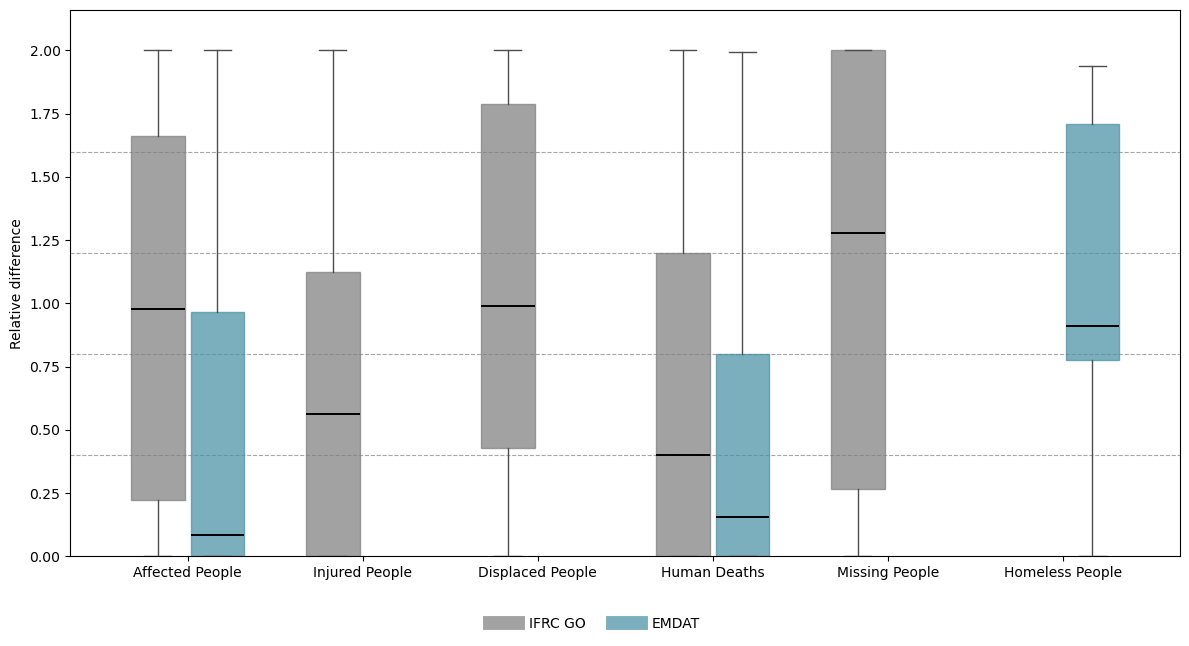

In [31]:
# Relative difference boxplot by impact category (style aligned with the stacked chart)
impact_categories = list(mapping_impact_type.keys())
x = np.arange(len(impact_categories))
width = 0.34

# Colors aligned with your previous figure
color_ifrc = "#7f7f7f"   # medium grey
color_emdat = "#4a90a4"  # muted blue-grey

fig, ax = plt.subplots(figsize=(12, 6))

# Build grouped boxplot data
box_data = []
box_positions = []
box_colors = []

for i, impactSubtype in enumerate(impact_categories):
    vals_ifrc = (
        df_matched_with_impact.get("ifrc_go", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "abs_rel_diff"]
        .dropna()
        .values
    )
    vals_emdat = (
        df_matched_with_impact.get("emdat", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impactSubtype, "abs_rel_diff"]
        .dropna()
        .values
    )

    if len(vals_ifrc) > 0:
        box_data.append(vals_ifrc)
        box_positions.append(i - width / 2)
        box_colors.append(color_ifrc)

    if len(vals_emdat) > 0:
        box_data.append(vals_emdat)
        box_positions.append(i + width / 2)
        box_colors.append(color_emdat)

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=width * 0.9,
    patch_artist=True,
    showfliers=False,
)

for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.72)
    patch.set_edgecolor(c)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.4)

for whisker in bp["whiskers"]:
    whisker.set_color("#4d4d4d")

for cap in bp["caps"]:
    cap.set_color("#4d4d4d")

# Horizontal dashed gridlines (as in your bar chart)
ymax = np.nanmax(np.concatenate([arr for arr in box_data if len(arr) > 0])) if box_data else 1
if not np.isfinite(ymax) or ymax <= 0:
    ymax = 1

grid_levels = np.linspace(0, ymax, 6)[1:-1]
for y in grid_levels:
    ax.axhline(y=y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(impact_categories)
ax.set_ylabel("Relative difference")
ax.set_ylim(0, ymax * 1.08)

# Legend under plot
legend_handles = [
    plt.Line2D([0], [0], color=color_ifrc, lw=10, alpha=0.72, label="IFRC GO"),
    plt.Line2D([0], [0], color=color_emdat, lw=10, alpha=0.72, label="EMDAT"),
]

fig.legend(
    handles=legend_handles,
    labels=["IFRC GO", "EMDAT"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False,
)

plt.tight_layout()
plt.show()

In [111]:
df_matched_with_impact["ifrc_go"][1]

,impactValue_final,location,locationOsm,impactSubtype,impactValue,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,locationAnnotation,...,parent_event,slug,summary,tab_one_title,tab_three_title,tab_two_title,translation_module_original_language,updated_at,rel_diff,match
32,124.0,Khost; Zabul; Faryab; Farah; Kapisa; Kunar; Ku...,Faryab Province; Herat; Nangarhar Province; Pa...,Injured People,124.0,exact,people,"[As of 28 August, 141 fatalities were reported...",0,"[As of 28 August, 141 fatalities were reported...",...,NaN,NaN,"<p class=""MsoNoSpacing"" style=""text-align: jus...",Additional Information,NaN,NaN,en,2024-06-03T18:15:18.094806Z,0.000000,True
39,84.0,Badakhshan; Badghis; Baghlan; Balkh; Diakindi;...,Badghis Province; Baghlan Province; Balkh; Gho...,Injured People,84.0,exact,people,"[A total of 41 deaths, 84 injuries, 8,273 dama...",0,"[A total of 41 deaths, 84 injuries, 8,273 dama...",...,NaN,NaN,"<p class=""MsoNormal"" style=""text-align: justif...",Additional Information,NaN,NaN,en,2024-05-25T05:17:32.889099Z,0.000000,True
224,4.0,Kiyange 1 and Ngagara-Sabe areas; Gatumba,Gatumba; Burundi,Injured People,4.0,exact,people,[This situation left 1 death and 4 injuries.],0,"[This situation left 1 death and 4 injuries., ...",...,NaN,NaN,ButerereBURUNDI has experienced unprecedented ...,Additional Information,NaN,NaN,en,2024-06-03T18:20:21.463237Z,0.000000,True
340,220.0,Kalehe Territory; South Kivu Province; Bushush...,Democratic Republic of Congo; Bushushu; Nyamukubi,Injured People,220.0,exact,people,[The injured needed to be rescued and evacuate...,0,[The disaster created vulnerabilities and had ...,...,NaN,NaN,"<p><span style=""font-size: 11.0pt; line-height...",Additional Information,NaN,NaN,fr,2024-06-03T12:29:08.459102Z,0.500000,False
354,11.0,Kalemie; Moba,Kalemie; Democratic Republic of Congo,Injured People,11.0,exact,people,[11 deaths and 8 injuries were reported in Kal...,0,[11 deaths and 8 injuries were reported in Kal...,...,NaN,NaN,"<p class=""MsoNormal"" style=""text-align: justif...",Additional Information,NaN,NaN,fr,2024-07-14T20:02:45.687598Z,0.482759,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2618,1908.0,northern Viet Nam; northern mountainous provin...,Hòa Bình Province; Yên Bái Province; Sơn La Pr...,Injured People,1908.0,exact,people,"[The VNDDMA reported 262 fatalities, 83 missin...",0,"[The report confirmed 262 fatalities, 83 missi...",...,NaN,NaN,<p>Cyclone Yagi has steadily strengthened all ...,Additional Information,NaN,NaN,en,2025-07-16T00:43:11.029197Z,0.000000,True
2643,28.0,,Yemen,Injured People,28.0,exact,people,"[According to reported data, over 205,800 peop...",0,"[According to reported data, over 205,800 peop...",...,NaN,NaN,NaN,Additional Information,NaN,NaN,en,2021-07-22T14:59:11.547641Z,0.727273,False
2649,41.0,,Yemen,Injured People,41.0,exact,people,"[Up till May 11th, YRCS needs' tracking report...",0,"[Up till May 11th, YRCS needs' tracking report...",...,NaN,NaN,"<p class=""MsoNormal"" style=""text-align: justif...",Additional Information,NaN,NaN,en,2024-06-03T18:13:17.321543Z,0.000000,True
2653,150.0,Al-Mahra Governorate; Hadramout; Shabwa; Al Gh...,Socotra Governorate; Hadramout - Ma'rib Road; ...,Injured People,150.0,exact,people,[More than 150 people were injured.],0,"[The reports of widespread ﬂooding, infrastruc...",...,NaN,NaN,<p>Tropical cyclone TEJ made landfall over the...,Additional Information,NaN,NaN,en,2023-11-02T09:32:11.319114Z,0.006645,True


In [109]:
error = {}
relative_error = {}
abs_relative_error = {}
mae = {}
rmse = {}

for external_source in ["emdat", "ifrc_go"] : 
    error[external_source] = []
    relative_error[external_source] = []
    abs_relative_error[external_source] = []
    mae[external_source] = []
    rmse[external_source] = []
    for impactSubtype in mapping_impact_type.keys() : 
        col = mapping_impact_type[impactSubtype][external_source]
        if col is None :
            mae[external_source].append(0)
            rmse[external_source].append(0)
            error[external_source].append(0)
            abs_relative_error[external_source].append(0)
            relative_error[external_source].append(0)
            continue

        df_matched = df_llm_all_geo_grp_linked[external_source].loc[df_llm_all_geo_grp_linked[external_source]["impactSubtype"] == impactSubtype]

        if external_source == "ifrc_go" : 
            df_matched["external_value"] = df_matched[impactSubtype]

        elif external_source == "emdat" : 
            df_matched["external_value"] = df_matched[col]

        df_matched = df_matched.dropna(subset=["external_value"])
        # Add errors metrics
        df_matched["error"] = df_matched["external_value"] - df_matched["impactValue_final"]

        df_matched["abs_relative_error"] = np.abs(df_matched["impactValue_final"] - df_matched["external_value"])/df_matched["impactValue_final"]
        df_matched["relative_error"] = (df_matched["impactValue_final"] - df_matched["external_value"])/df_matched["impactValue_final"]

        df_matched["abs_error"] = (df_matched["impactValue_final"] - df_matched["external_value"]).abs()

        # Squared error per row (for RMSE)
        df_matched["squared_error"] = (df_matched["impactValue_final"] - df_matched["external_value"])**2

        error[external_source].append(df_matched["error"].mean())
        relative_error[external_source].append(df_matched["relative_error"].mean())
        abs_relative_error[external_source].append(df_matched["abs_relative_error"].mean())
        mae[external_source].append(df_matched["abs_error"].mean())
        rmse[external_source].append(np.sqrt(df_matched["squared_error"].mean()))

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_26476\3575627123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched["external_value"] = df_matched[col]
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_26476\3575627123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matched["external_value"] = df_matched[col]
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_26476\3575627123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

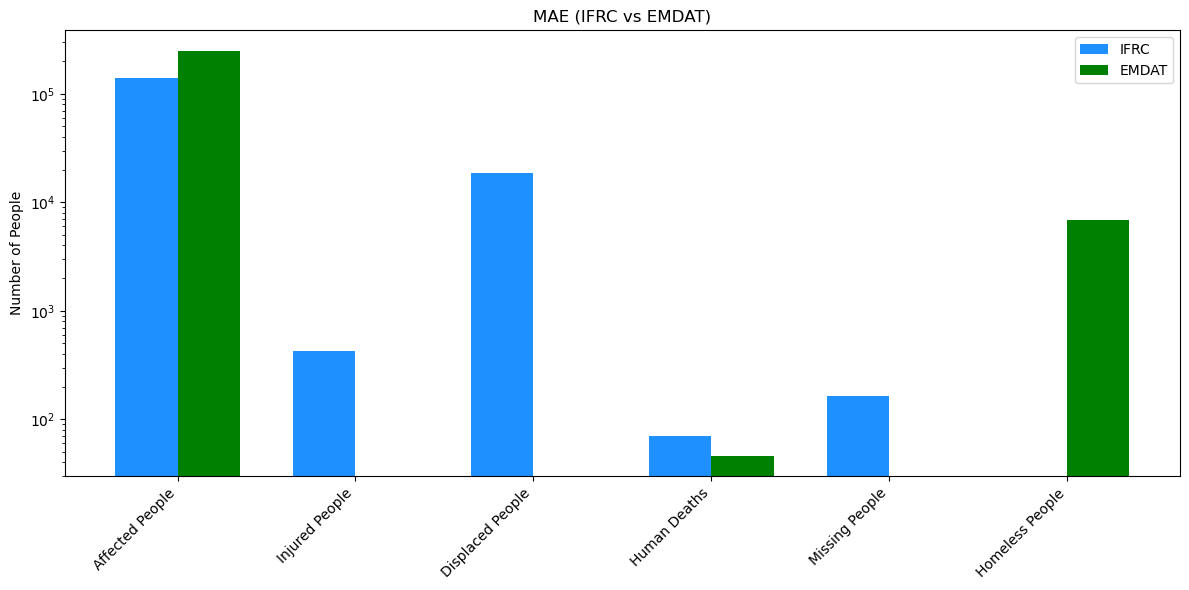

In [103]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, mae["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, mae["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of People")
ax.set_title("MAE (IFRC vs EMDAT)")
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

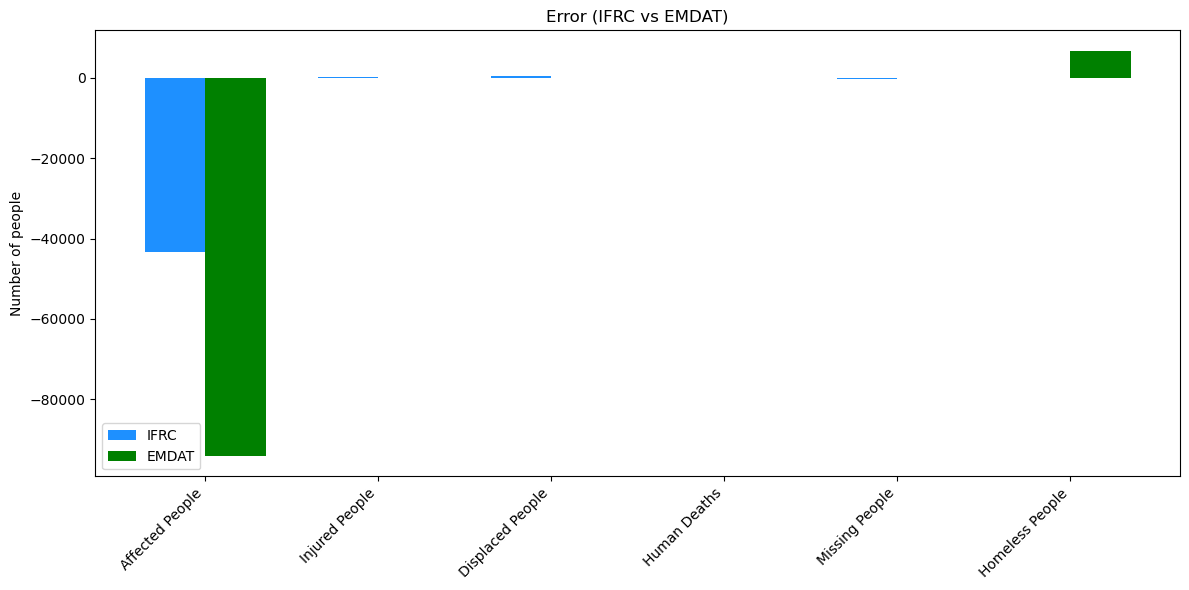

In [104]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, error["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, error["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
ax.set_ylabel("Number of people")
ax.set_title("Error (IFRC vs EMDAT)")
# ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

c:\Users\lhasbini\anaconda3\envs\ifrc_llm_311\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\lhasbini\anaconda3\envs\ifrc_llm_311\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


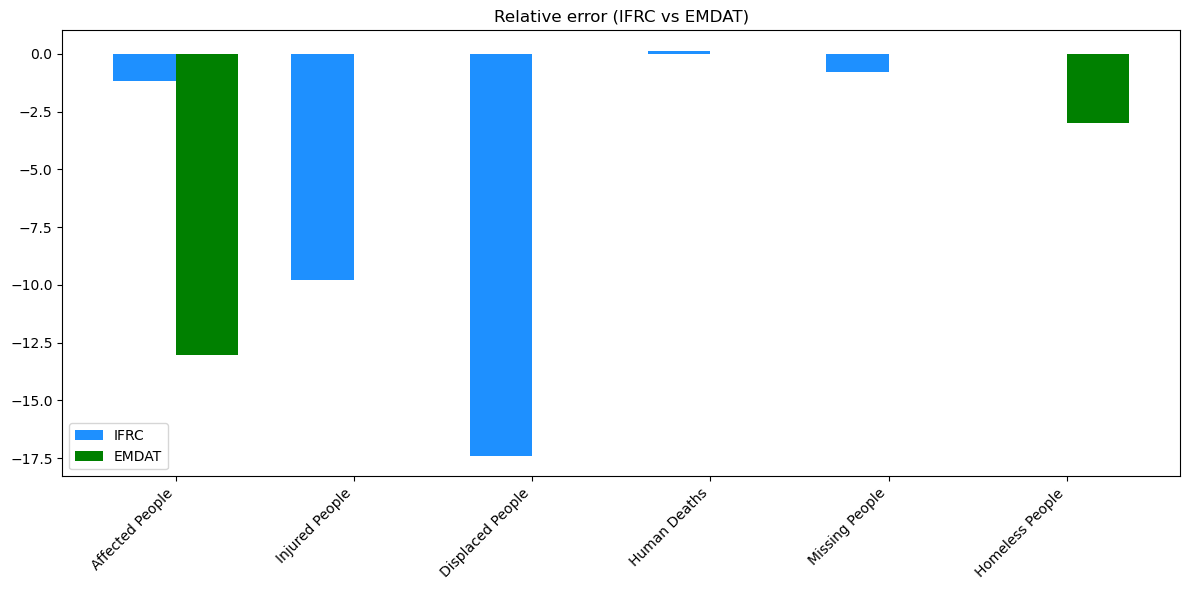

In [110]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, relative_error["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, relative_error["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
# ax.set_ylabel("Number of Appeals")
ax.set_title("Relative error (IFRC vs EMDAT)")
# ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

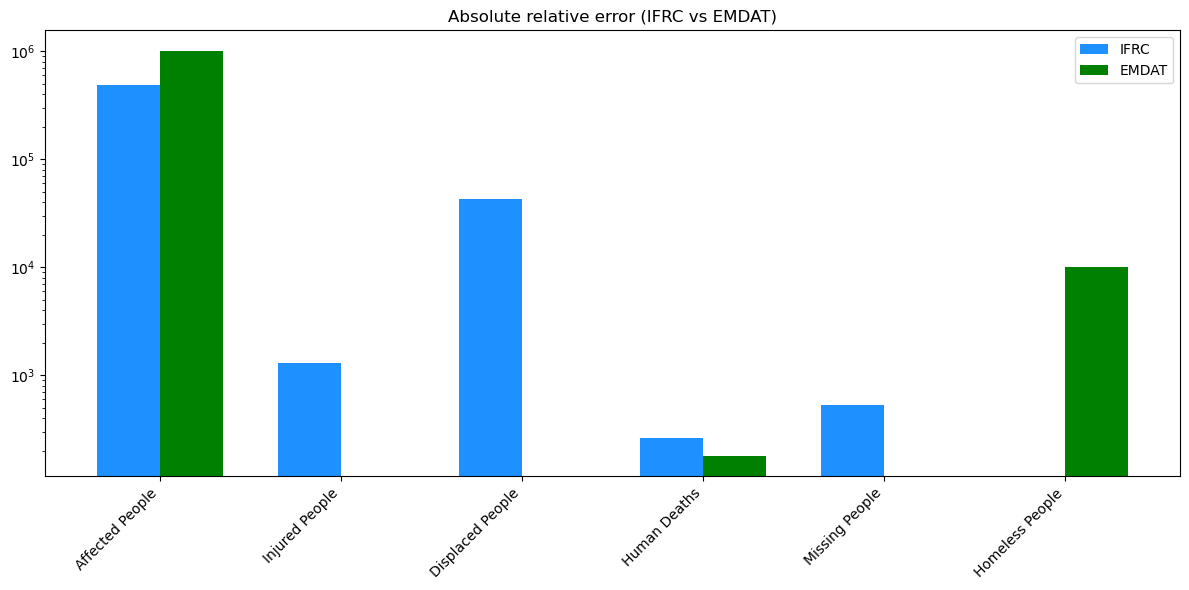

In [106]:
x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Define colors like in your previous example
colors_ifrc = ["skyblue", "dodgerblue"]      # all / perfect match
colors_emdat = ["lightgreen", "green"]       # all / perfect match

# IFRC bars
# ax.bar(x - width/2, nb_matched_ifrc, width, label="IFRC - all", color=colors_ifrc[0])
ax.bar(x - width/2, rmse["ifrc_go"], width, label="IFRC", color=colors_ifrc[1])

# EMDAT bars
# ax.bar(x + width/2, nb_matched_emdat, width, label="EMDAT - all", color=colors_emdat[0])
ax.bar(x + width/2, rmse["emdat"], width, label="EMDAT", color=colors_emdat[1])

# Labels
ax.set_xticks(x)
ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
# ax.set_ylabel("Number of Appeals")
ax.set_title("Absolute relative error (IFRC vs EMDAT)")
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

## Bar plot comparison

## Bar plot relative error 

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_35752\2436865138.py:149: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



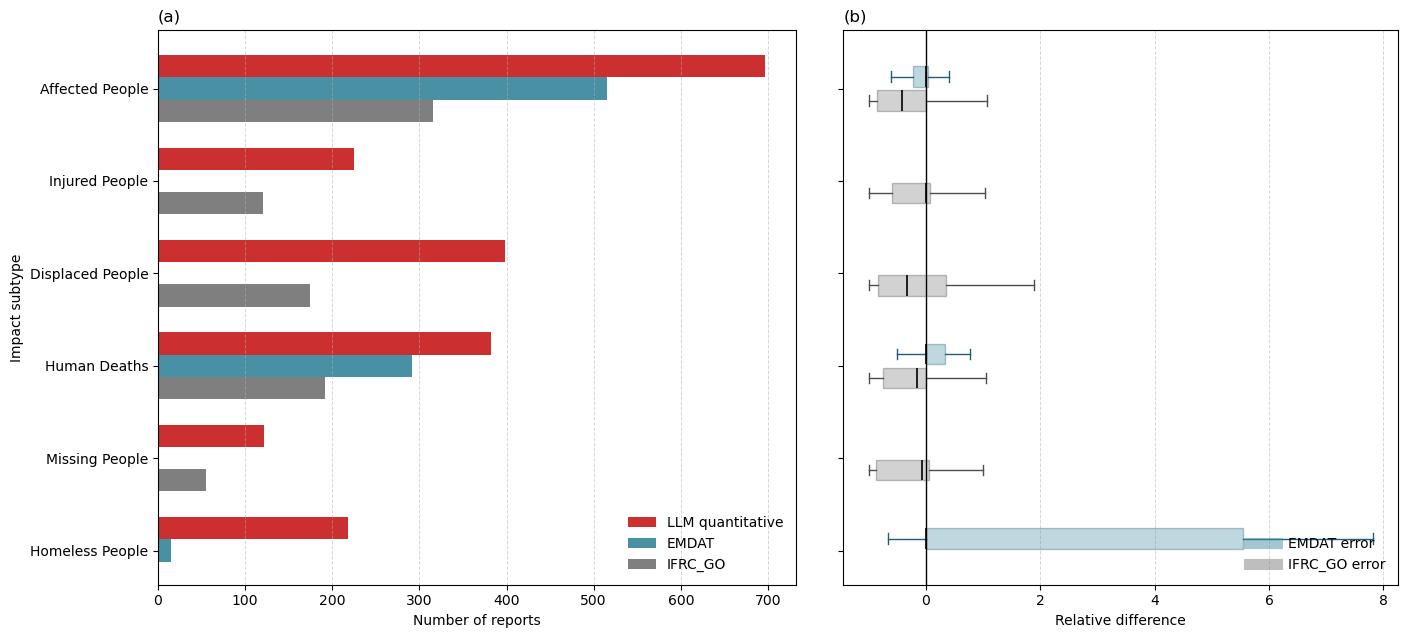

In [177]:
# (a)-(b) Two-column aligned plot: report counts and rel_diff distributions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

impact_types = list(mapping_impact_type.keys())
n_types = len(impact_types)
y = np.arange(n_types)

# Pick IFRC key available in both dictionaries (prefer IFRC GO)
if "ifrc_go" in nb_matched and "ifrc_go" in df_matched_with_impact:
    ifrc_key = "ifrc_go"
else:
    ifrc_key = "ifrc_monty"

# Counts for panel (a)
llm_counts = np.array(nb_report_with_impact_llm, dtype=float)
emdat_counts = np.array(nb_matched.get("emdat", [0] * n_types), dtype=float)
ifrc_counts = np.array(nb_matched.get(ifrc_key, [0] * n_types), dtype=float)

# Create side-by-side panels sharing y to guarantee alignment
fig, (ax_a, ax_b) = plt.subplots(
    1,
    2,
    figsize=(16, max(6, 0.7 * n_types + 3)),
    gridspec_kw={"width_ratios": [1.15, 1.0], "wspace": 0.08},
    sharey=True,
 )

# =====================
# (a) Horizontal grouped bar plot
# =====================
bar_h = 0.24
ax_a.barh(y - bar_h, llm_counts, height=bar_h, color="#cc2f2f", label="LLM quantitative")
ax_a.barh(y, emdat_counts, height=bar_h, color="#4a90a4", label="EMDAT")
ax_a.barh(y + bar_h, ifrc_counts, height=bar_h, color="#7f7f7f", label=ifrc_key.upper())

# ax_flow.set_ylim(y_rows.min() - 1, y_rows.max() + 1)
# ax_flow.set_xticks([])
# ax_flow.set_yticks(y_rows)
# ax_flow.set_yticklabels(impact_subtypes)


ax_a.set_yticks(y)
ax_a.set_yticklabels(impact_subtypes)
ax_a.set_ylabel("Impact subtype")
ax_a.invert_yaxis()
ax_a.set_xlabel("Number of reports")
ax_a.set_title("(a)", loc="left")
ax_a.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_a.legend(loc="lower right", frameon=False)

# =====================
# (b) Horizontal boxplot of rel_diff (EMDAT and IFRC)
# =====================
box_h = 0.26
emdat_pos = y - box_h / 2
ifrc_pos = y + box_h / 2

box_vals_emdat = []
box_pos_emdat = []
box_vals_ifrc = []
box_pos_ifrc = []

for i, impact_type in enumerate(impact_types):
    vals_emdat = (
        df_matched_with_impact.get("emdat", pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impact_type, "rel_diff"]
        .dropna()
        .values
    )
    vals_ifrc = (
        df_matched_with_impact.get(ifrc_key, pd.DataFrame())
        .loc[lambda d: d["impactSubtype"] == impact_type, "rel_diff"]
        .dropna()
        .values
    )

    if len(vals_emdat) > 0:
        box_vals_emdat.append(vals_emdat)
        box_pos_emdat.append(emdat_pos[i])

    if len(vals_ifrc) > 0:
        box_vals_ifrc.append(vals_ifrc)
        box_pos_ifrc.append(ifrc_pos[i])

if box_vals_emdat:
    bp_emdat = ax_b.boxplot(
        box_vals_emdat,
        positions=box_pos_emdat,
        vert=False,
        widths=box_h * 0.85,
        patch_artist=True,
        showfliers=False,
    )

    for box in bp_emdat["boxes"]:
        box.set_facecolor("#4a90a4")
        box.set_alpha(0.35)
        box.set_edgecolor("#1f5f78")
    for median in bp_emdat["medians"]:
        median.set_color("black")
        median.set_linewidth(1.2)
    for whisker in bp_emdat["whiskers"]:
        whisker.set_color("#1f5f78")
    for cap in bp_emdat["caps"]:
        cap.set_color("#1f5f78")

if box_vals_ifrc:
    bp_ifrc = ax_b.boxplot(
        box_vals_ifrc,
        positions=box_pos_ifrc,
        vert=False,
        widths=box_h * 0.85,
        patch_artist=True,
        showfliers=False,
    )

    for box in bp_ifrc["boxes"]:
        box.set_facecolor("#7f7f7f")
        box.set_alpha(0.35)
        box.set_edgecolor("#4d4d4d")
    for median in bp_ifrc["medians"]:
        median.set_color("black")
        median.set_linewidth(1.2)
    for whisker in bp_ifrc["whiskers"]:
        whisker.set_color("#4d4d4d")
    for cap in bp_ifrc["caps"]:
        cap.set_color("#4d4d4d")

ax_b.axvline(0, color="black", linewidth=1)
ax_b.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_b.set_xlabel("Relative difference")
ax_b.set_title("(b)", loc="left")

# # Keep impact subtype labels visible (left panel) and keep rows aligned across both panels
ax_b.set_yticks(y)
ax_b.tick_params(axis="y", labelleft=False)
ax_a.set_yticklabels(impact_subtypes)

# Legend for panel (b)
legend_boxes = [
    plt.Line2D([0], [0], color="#4a90a4", lw=8, alpha=0.5, label="EMDAT error"),
    plt.Line2D([0], [0], color="#7f7f7f", lw=8, alpha=0.5, label=f"{ifrc_key.upper()} error"),
]
ax_b.legend(handles=legend_boxes, loc="lower right", frameon=False)

# fig.suptitle("Aligned comparison by impact subtype: report counts vs rel_diff distributions", y=0.98)
plt.tight_layout()
plt.show()

## Differences in IFRC Go

In [169]:
df = df_matched_with_impact["ifrc_go"]

# keep only keys that are actual columns
valid_cols = [c for c in mapping_impact_type.keys() if c in df.columns]

df_result = (
    df.sort_values("rel_diff")
      .head(10)[
          ["appealCode", "impactSubtype", "impactValue_final", "abs_diff", "rel_diff"] + valid_cols
      ]
)

In [170]:
df_result

,appealCode,impactSubtype,impactValue_final,abs_diff,rel_diff,Affected People,Injured People,Displaced People,Human Deaths,Missing People
66,MDRCO018,Affected People,0.000000,2000.000000,-2.000000,2000.0,3.0,NaN,5.0,9.0
845,MDRPH056,Missing People,0.000000,17.000000,-2.000000,1695975.0,35.0,348420.0,84.0,17.0
222,MDRPH052,Affected People,2.397336,180436.602664,-1.999947,180439.0,2.0,11041.0,1.0,NaN
373,MDRKE047,Injured People,1.000000,4897.000000,-1.999184,4898.0,4898.0,4898.0,14.0,3.0
555,MDRPH045,Displaced People,289.049000,452133.951000,-1.997446,4462997.0,1147.0,452423.0,407.0,82.0
203,MDRNP015,Affected People,36.250000,36338.750000,-1.996018,36375.0,23.0,10565.0,NaN,1.0
671,MDRHT018,Human Deaths,2.248000,2204.752000,-1.995930,NaN,12268.0,NaN,2207.0,320.0
818,MDRHT018,Missing People,0.329000,319.671000,-1.995892,NaN,12268.0,NaN,2207.0,320.0
357,MDRHT018,Injured People,12.763000,12255.237000,-1.995843,NaN,12268.0,NaN,2207.0,320.0
55,MDRCG018,Affected People,46.652000,39405.348000,-1.995276,39452.0,25.0,6552.0,2.0,5.0


In [167]:
(2.397336 - 180439.0)/2.397336

-75265.46243997503

In [168]:
(180439.0 - 2.397336)/180439.0

0.9999867138700613

In [142]:
df_llm_all.loc[(df_llm_all["appealCode"] == "MDRKE056") & (df_llm_all["impactSubtype"] == "Affected People")]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,country_robust_iso3,locationLowestAdmin,flag_geocoding_country,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,impactValueApprox,flag_pop_cntry,flag_impactSubtype_merged
6522,Affected People,139135.0,NaN,NaN,exact,people,"['People Affected: 139,135 people']",0,"[Mombasa, Kwale, Tana River, Taita-Taveta, Gar...","['Targeted Areas: Mombasa, Kwale, Tana River, ...",...,[KEN],ADM_1,0.0,2.0,"['Garissa', 'Tana River County', 'West Pokot',...","['Garissa', 'Tana River', 'West Pokot', 'Narok...",['KEN'],NaN,False,False
6560,Affected People,36.0,NaN,NaN,exact,people,['Seven people died in OlJorai village in Naku...,0,"[Nakuru county, West Pokot County, OlJorai vil...",['Seven people died in OlJorai village in Naku...,...,[KEN],ADM_0,3.0,0.0,"['West Pokot', 'Kenya']","['West Pokot', 'Kenya']",['KEN'],NaN,False,False
6563,Affected People,8000.0,NaN,NaN,NaN,NaN,['lake Kanyaboli broke its banks leading to th...,0,[lake Kanyaboli],['lake Kanyaboli broke its banks leading to th...,...,[KEN],ADM_2,0.0,0.0,['Lake Kanyaboli'],['Siaya'],['KEN'],NaN,False,False


In [144]:
df_ifrc_go.loc[df_ifrc_go["appealCode"] == "MDRKE056"]

,Affected People,Affected People Source,Displaced People,Displaced People Source,Human Deaths,Human Deaths Source,Injured People,Injured People Source,Missing People,Missing People Source,...,name,num_affected,parent_event,slug,summary,tab_one_title,tab_three_title,tab_two_title,translation_module_original_language,updated_at
828,36432.0,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,KEN: Flood - 2023-03 - Floods,NaN,NaN,NaN,<p>The March April May season started this yea...,Additional Information,NaN,NaN,en,2024-06-03T18:13:08.320658Z


In [145]:
df_ifrc_monty.loc[df_ifrc_monty["appealCode"] == "MDRKE056"]

,Unnamed: 0,geometry,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,monty:hazard_codes,monty:country_codes,monty:episode_number,id,impact_type,impact_value,impact_category,impact_estimate_type,appealCode
371,371,MULTIPOLYGON (((41.905170000000055 3.980320000...,"source, impact",KEN: Flood - 2023-03 - Floods,2023-03-22 00:00:00+00:00,<p>The March April May season started this yea...,2023-03-22T00:00:00+00:00,879890a2-f868-41bb-bc04-69db0b3344a3,20230322-KEN-NAT-HYD-FLO-FLO-1-GCDB,2023-03-22T00:00:00+00:00,FL,KEN,1,ifrcevent-impact--6419-affected_total,Affected People,36432,people,primary,MDRKE056
